<a href="https://colab.research.google.com/github/luigi-radicchi/NASA-EONET-API-and-EDA/blob/main/notebook/NASA_EONET_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [829]:
# import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [830]:
# import events table from EONET NASA API
import requests

url = 'https://eonet.gsfc.nasa.gov/api/v2.1/events'


response = requests.get(url)

data = response.json()



In [831]:
data.keys()

dict_keys(['title', 'description', 'link', 'events'])

In [832]:
data = data['events']

In [833]:
events = pd.json_normalize(data)

In [834]:
events.head()
# noted that one event can have more categories, sources and more geometries

,id,title,description,link,categories,sources,geometries
0,EONET_23868,"Emergency Stabilization BAER McConnell, Humbol...",,https://eonet.gsfc.nasa.gov/api/v2.1/events/EO...,"[{'id': 8, 'title': 'Wildfires'}]","[{'id': 'IRWIN', 'url': 'https://irwin.doi.gov...","[{'date': '2026-09-03T13:03:00Z', 'type': 'Poi..."
1,EONET_23869,"Wildfire Ayers Pond, Prairie, Montana","25 Miles SE from Terry, MT",https://eonet.gsfc.nasa.gov/api/v2.1/events/EO...,"[{'id': 8, 'title': 'Wildfires'}]","[{'id': 'IRWIN', 'url': 'https://irwin.doi.gov...","[{'date': '2026-09-03T01:45:00Z', 'type': 'Poi..."
2,EONET_23870,"Wildfire Snow, Custer, Montana","30 Miles E from Miles City, MT",https://eonet.gsfc.nasa.gov/api/v2.1/events/EO...,"[{'id': 8, 'title': 'Wildfires'}]","[{'id': 'IRWIN', 'url': 'https://irwin.doi.gov...","[{'date': '2026-09-02T22:16:00Z', 'type': 'Poi..."
3,EONET_23800,Hurricane Marie,,https://eonet.gsfc.nasa.gov/api/v2.1/events/EO...,"[{'id': 10, 'title': 'Severe Storms'}]","[{'id': 'JTWC', 'url': 'https://www.metoc.navy...","[{'date': '2026-09-01T06:00:00Z', 'type': 'Poi..."
4,EONET_23739,Tropical Storm Edouard,,https://eonet.gsfc.nasa.gov/api/v2.1/events/EO...,"[{'id': 10, 'title': 'Severe Storms'}]","[{'id': 'NOAA_NHC', 'url': 'https://www.nhc.no...","[{'date': '2026-09-01T03:00:00Z', 'type': 'Poi..."


In [835]:
# getting the dimensions of the events table and the dimensions for the normalized categories, sources and geometries tables
print(events.shape)
print(events['categories'].apply(lambda x: len(x)).sum())
print(events['sources'].apply(lambda x: len(x)).sum())
print(events['geometries'].apply(lambda x: len(x)).sum())
# the categories are repplaceable in 1:1. The events wih more than 1 source will be concatenated, the events with more
# than one location and time will be considered as only the starting point and location

(7148, 7)
7148
7172
7944


In [836]:
events['sources'] = events['sources'].apply(lambda x: ', '.join(c['id'] for c in x))   # unpacking and joining sources
events['date'] = events['geometries'].apply(lambda x: ', '.join(c['date'] for c in x))   # unpacking multiple date
events['first observation'] = events['date'].str.split(',').str[0]   # getting only first time observation
events.drop(columns = ['date'], inplace = True)   # removing the original multi-date column
events['first space'] = events['geometries'].apply(lambda x: x[0]['coordinates'] if x else None )   # getting first space observation
events.drop(columns = ['geometries'], inplace = True)   # removing the original multi-date multi-space column
events['categories'] = events['categories'].apply(lambda x: ', '.join(c['title'] for c in x))   # categories are 1:1

In [837]:
events.head()

,id,title,description,link,categories,sources,first observation,first space
0,EONET_23868,"Emergency Stabilization BAER McConnell, Humbol...",,https://eonet.gsfc.nasa.gov/api/v2.1/events/EO...,Wildfires,IRWIN,2026-09-03T13:03:00Z,"[-117.74215, 41.517567]"
1,EONET_23869,"Wildfire Ayers Pond, Prairie, Montana","25 Miles SE from Terry, MT",https://eonet.gsfc.nasa.gov/api/v2.1/events/EO...,Wildfires,IRWIN,2026-09-03T01:45:00Z,"[-104.83045, 46.65069]"
2,EONET_23870,"Wildfire Snow, Custer, Montana","30 Miles E from Miles City, MT",https://eonet.gsfc.nasa.gov/api/v2.1/events/EO...,Wildfires,IRWIN,2026-09-02T22:16:00Z,"[-105.185017, 46.48575]"
3,EONET_23800,Hurricane Marie,,https://eonet.gsfc.nasa.gov/api/v2.1/events/EO...,Severe Storms,"JTWC, NOAA_NHC",2026-09-01T06:00:00Z,"[-108.1, 14.1]"
4,EONET_23739,Tropical Storm Edouard,,https://eonet.gsfc.nasa.gov/api/v2.1/events/EO...,Severe Storms,NOAA_NHC,2026-09-01T03:00:00Z,"[-91.8, 28.6]"


In [838]:
# create dimtable of sources to associate the institue with the source id
import requests

url = 'https://eonet.gsfc.nasa.gov/api/v2.1/sources'


response = requests.get(url)

sources_dimtable = response.json()


In [839]:
sources_dimtable.keys()

dict_keys(['title', 'description', 'link', 'sources'])

In [840]:
sources_dimtable = pd.json_normalize(sources_dimtable['sources'])

In [841]:
sources_dimtable.head()

,id,title,source,link
0,AVO,Alaska Volcano Observatory,https://www.avo.alaska.edu/,https://eonet.gsfc.nasa.gov/api/v2.1/events?so...
1,ABFIRE,Alberta Wildfire,https://wildfire.alberta.ca/,https://eonet.gsfc.nasa.gov/api/v2.1/events?so...
2,AU_BOM,Australia Bureau of Meteorology,http://www.bom.gov.au/,https://eonet.gsfc.nasa.gov/api/v2.1/events?so...
3,BYU_ICE,Brigham Young University Antarctic Iceberg Tra...,http://www.scp.byu.edu/data/iceberg/database1....,https://eonet.gsfc.nasa.gov/api/v2.1/events?so...
4,BCWILDFIRE,British Columbia Wildfire Service,http://bcwildfire.ca/,https://eonet.gsfc.nasa.gov/api/v2.1/events?so...


In [842]:
# verifying the entries
print(events.isnull().sum())
# although in 'description' there are empty entries


id                   0
title                0
description          0
link                 0
categories           0
sources              0
first observation    0
first space          0
dtype: int64


In [843]:
# managing the date column
events['first observation'] = pd.to_datetime(events['first observation'])   # convert to datetime
events['year'] = events['first observation'].dt.strftime('%Y').astype('int64')   # create year
events['year month number'] = events['first observation'].dt.strftime('%Y-%m')   # create year-number of month
events['year month name'] = events['first observation'].dt.strftime('%Y-%b')   # creat year-name of month

In [844]:
# defining latitude and longitude to be able to create geo maps
events['longitude'] = events['first space'].apply(lambda x: x[0] if x else None)
events['latitude'] = events['first space'].apply(lambda x: x[1] if x else None)


In [845]:
#set(events['title'])
US_states = ['Alabama',
 'Alaska',
 'Arizona',
 'Arkansas',
 'California',
 'Colorado',
 'Florida',
 'Georgia',
 'Hawaii',
 'Idaho',
 'Illinois',
 'Indiana',
 'Iowa',
 'Kansas',
 'Kentucky',
 'Louisiana',
 'Maryland',
 'Massachusetts',
 'Michigan',
 'Minnesota',
 'Mississippi',
 'Missouri',
 'Montana',
 'Nebraska',
 'Nevada',
 'New Jersey',
 'New Mexico',
 'New York',
 'North Carolina',
 'North Dakota',
 'Ohio',
 'Oklahoma',
 'Oregon',
 'Pennsylvania',
 'South Carolina',
 'South Dakota',
 'Tennessee',
 'Texas',
 'Utah',
 'Virginia',
 'Washington',
 'West Virginia',
 'Wisconsin',
 'Wyoming']


In [846]:
# extract the US state to insert in the table
def state_extraction(x):
  x = str(x)
  for state in US_states:
    if state in x:
      x = state
      break

  return x

events['temporary'] = events['title'].apply(state_extraction)


In [847]:
# compile the nation as USA if a US state is present
def USA_filling(x):
  x = str(x)
  if x in US_states:
    x = x
  else:
    x = ''
  return x

events['State'] = events['temporary'].apply(USA_filling)

In [848]:
# fill the other nations
def nation_extraction(x):
  x = str(x)
  if x in US_states:
    x = 'USA'
  else:
    if ',' in x:
      x = x.partition(', ')
      x = x[2]
    elif 'in' in x:
      x = x.partition('in ')
      x = x[2]
      x = x.partition(' 1')
      x = x[0]


    else:
      x = 'Open sea'

  return x
events['Nation'] = events['temporary'].apply(nation_extraction)

In [849]:
# clean the other nations
def applier(x):
  if ' 1' in x:
    x = x.partition(' 1')
    x = x[0]
  else:
    x = x
  return x
events['Nation'] = events['Nation'].apply(applier)

events['Nation'] = events['Nation'].replace('Brazil, Paraguay', 'Brazil')
events['Nation'] = events['Nation'].replace('Cote d&#039;Ivoire', 'Cote de ivoire')

In [850]:
# deleting the columns no more needed
events.drop(columns = 'description', inplace = True)
events.drop(columns = 'link', inplace = True)
events.drop(columns = 'temporary', inplace = True)

In [851]:
# table of events after cleaning
events.head()

,id,title,categories,sources,first observation,first space,year,year month number,year month name,longitude,latitude,State,Nation
0,EONET_23868,"Emergency Stabilization BAER McConnell, Humbol...",Wildfires,IRWIN,2026-09-03 13:03:00+00:00,"[-117.74215, 41.517567]",2026,2026-09,2026-Sep,-117.742150,41.517567,Nevada,USA
1,EONET_23869,"Wildfire Ayers Pond, Prairie, Montana",Wildfires,IRWIN,2026-09-03 01:45:00+00:00,"[-104.83045, 46.65069]",2026,2026-09,2026-Sep,-104.830450,46.650690,Montana,USA
2,EONET_23870,"Wildfire Snow, Custer, Montana",Wildfires,IRWIN,2026-09-02 22:16:00+00:00,"[-105.185017, 46.48575]",2026,2026-09,2026-Sep,-105.185017,46.485750,Montana,USA
3,EONET_23800,Hurricane Marie,Severe Storms,"JTWC, NOAA_NHC",2026-09-01 06:00:00+00:00,"[-108.1, 14.1]",2026,2026-09,2026-Sep,-108.100000,14.100000,,Open sea
4,EONET_23739,Tropical Storm Edouard,Severe Storms,NOAA_NHC,2026-09-01 03:00:00+00:00,"[-91.8, 28.6]",2026,2026-09,2026-Sep,-91.800000,28.600000,,Open sea


In [852]:
# number and type of events
events['categories'].value_counts()
# almost only wildfires have been recorded

,count
categories,
Wildfires,7077
Sea and Lake Ice,33
Volcanoes,32
Severe Storms,6


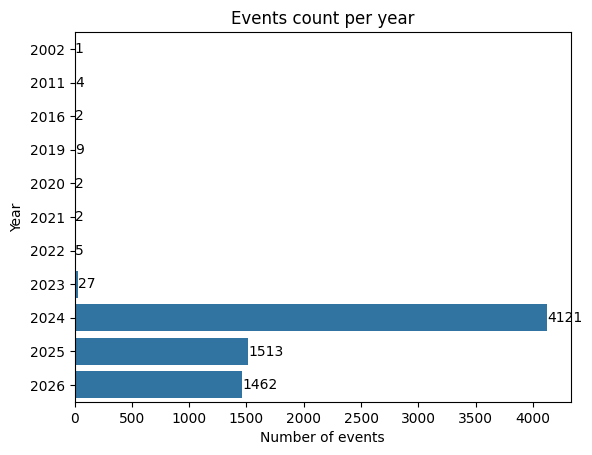

In [853]:
# year distribution
ax = sns.countplot(data = events, y = 'year')
ax.set_title('Events count per year')
ax.set_xlabel('Number of events')
ax.set_ylabel('Year')
for container in ax.containers:
  ax.bar_label(container)
# most of the events recorder occured in 2024, 2025 and 2026

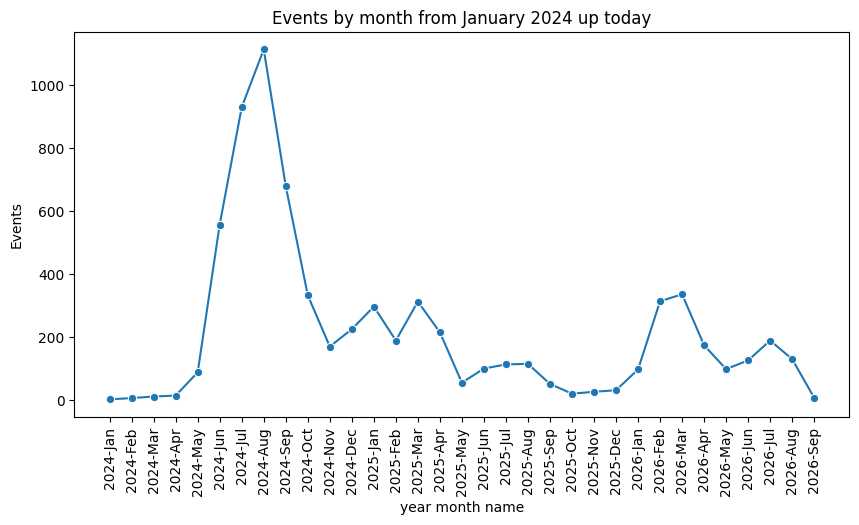

In [854]:
# detailed analysis based on month starting from jan-2024
plt.figure(figsize=(10, 5))
events_count_by_month = events.groupby(['year month number', 'year month name', 'year']).count().reset_index()
events_count_by_month = events_count_by_month[events_count_by_month['year'] >= 2024]
ax = sns.lineplot(data = events_count_by_month, x = 'year month name', y = 'id', marker = 'o')
plt.xticks(rotation=90)
plt.title('Events by month from January 2024 up today')
ax.set_ylabel('Events')
plt.show()
# the majority of events occured during summer 2024, since all events ara almost wildfires it is possible that summer has been critical

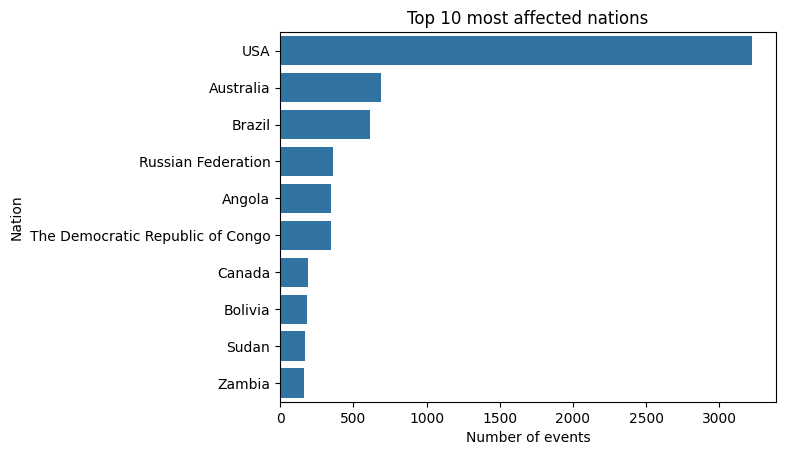

In [855]:
# most affected nations
events_count_by_nation = events.groupby(['Nation']).count().reset_index()
events_count_by_nation = events_count_by_nation.sort_values(by = 'id', ascending = False).iloc[0:10]
ax = sns.barplot(data = events_count_by_nation, y = 'Nation', x= 'id')
plt.title('Top 10 most affected nations')
ax.set_xlabel('Number of events')
plt.show()

Text(0.5, 0, 'Number of events')

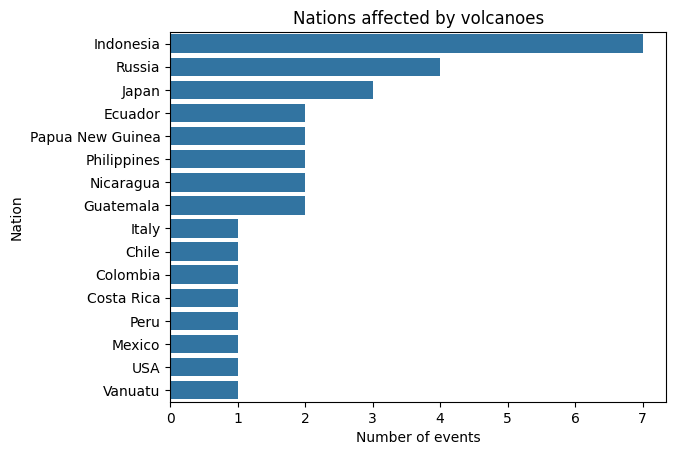

In [856]:
# most affected nations by volcanoes
#events_count_by_nation_volcanoes =
events_count_by_nation_volcanoes = events[events['categories'] == 'Volcanoes'].reset_index()
events_count_by_nation_volcanoes['Nation'] = events_count_by_nation_volcanoes['Nation'].replace('', 'Mexico')
events_count_by_nation_volcanoes = events_count_by_nation_volcanoes.groupby(['Nation']).count().reset_index()
events_count_by_nation_volcanoes = events_count_by_nation_volcanoes.sort_values(by = 'id', ascending = False)
ax = sns.barplot(data = events_count_by_nation_volcanoes, y = 'Nation', x = 'id')
plt.title('Nations affected by volcanoes')
ax.set_xlabel('Number of events')

In [857]:
# create a df of the oberving events by each institute, then merge with the full name
source_counter_df = (events['sources'].str.split(',').explode().str.strip().value_counts().reset_index())
source_counter_df.columns = ['sources', 'count']
merged_df = source_counter_df.set_index('sources').join(sources_dimtable.set_index('id'))
merged_df.drop(columns = 'source', inplace = True)
merged_df.drop(columns = 'link', inplace = True)
merged_df
# almost all the observation come from Global Disaster Alert and control Coordination system (GDACS)
# and the Integrated reporting of wildfire information (IRWIN)

,count,title
sources,,
GDACS,3856,Global Disaster Alert and Coordination System
IRWIN,3224,Integrated Reporting of Wildfire Information (...
NATICE,33,U.S. National Ice Center
SIVolcano,32,Smithsonian Institution Global Volcanism Program
EO,7,Earth Observatory
BYU_ICE,6,Brigham Young University Antarctic Iceberg Tra...
JTWC,5,Joint Typhoon Warning Center
NOAA_NHC,4,National Hurricane Center
Earthdata,1,Earthdata


In [858]:
# create a graph of the wildfires among the USA
import plotly.express as px

# create a dictionary to load the state name
replacement_dict ={ 'Alabama':	'AL',
'Alaska':	'AK',
'Arizona':	'AZ',
'Arkansas':	'AR',
'California':	'CA',
'Colorado':	'CO',
'Connecticut':' CT',
'Delaware':	'DE',
'District of Columbia':	'DC',
'Florida':	'FL',
'Georgia':	'GA',
'Hawaii':	'HI',
'Idaho':	'ID',
'Illinois':	'IL',
'Indiana':	'IN',
'Iowa':	'IA',
'Kansas':	'KS',
'Kentucky':	'KY',
'Louisiana':	'LA',
'Maine':	'ME',
'Maryland':	'MD',
'Massachusetts':	'MA',
'Michigan':	'MI',
'Minnesota':	'MN',
'Mississippi':	'MS',
'Missouri':	'MO',
'Montana':	'MT',
'Nebraska':	'NE',
'Nevada':	'NV',
'New Hampshire':	'NH',
'New Jersey':	'NJ',
'New Mexico':	'NM',
'New York':	'NY',
'North Carolina':	'NC',
'North Dakota':	'ND',
'Ohio':	'OH',
'Oklahoma':	'OK',
'Oregon':	'OR',
'Pennsylvania':	'PA',
'Rhode Island':	'RI',
'South Carolina':	'SC',
'South Dakota':	'SD',
'Tennessee':	'TN',
'Texas':	'TX',
'Utah':	'UT',
'Vermont':	'VT',
'Virginia':	'VA',
'Washington':	'WA',
'West Virginia':	'WV',
'Wisconsin':	'WI',
'Wyoming':	'WY' }

# create the dataframe
wildfire_USA = events[events['Nation'] == 'USA']
wildfire_USA = wildfire_USA[wildfire_USA['categories'] == 'Wildfires']
wildfire_USA = wildfire_USA.groupby(['State']).count().reset_index()
wildfire_USA = wildfire_USA.sort_values(by = 'id', ascending = False)
wildfire_USA['State_code'] = wildfire_USA['State']
wildfire_USA['State_code'] =wildfire_USA['State_code'].replace(replacement_dict)
wildfire_USA['id'].astype('int64')
wildfire_USA = wildfire_USA.rename(columns={'id': 'events'})

# create the map
fig = px.choropleth(
    wildfire_USA,
    locations='State_code',
    locationmode='USA-states',
    color='events',
    scope='usa',
    color_continuous_scale='Reds',
    title='Wildfire distribution among USA'
)

fig.show()

In [859]:
# create a whole world graph for all the categories
import plotly.express as px

fig = px.scatter_geo(events,lat="latitude",lon="longitude",color="categories")

fig.show()